# 03 · Citrus candidate shortlist

**Goal** (README.md §8.1): a short list of host genes/promoters for the collaborator's
follow-up (reporter assay in galls). No single statistic is trusted: several simple ranking methods,
top 20 from each, compared by hand alongside the annotation table. This notebook is the
non-cluster part of that: everything after `make` has produced count matrices.

| method | what it measures | inputs | status |
|---|---|---|---|
| 1 gall expression | promoter **strength** in the galls themselves | gall counts | §5 below (also `make shortlist`) |
| 2 DESeq2 shrunken log2FC | change vs healthy tissue, with a variance model | baselines + R | not yet (R/DESeq2 not installed) |
| 3 percentile rank shift | change vs healthy tissue, depth-robust | baselines | §7, runs when the baseline matrix exists |
| 4 rank products | change that is consistent across galls | baselines | §7 |
| 5 RankComp | gene-pair order flips | baselines | not yet |
| 6 tissue specificity (tau) | gall-specific vs stem/leaf/bark/root/callus | baselines | §7 |

Galls: one Hamlin sweet orange (strain 29) and four Carrizo citrange (strain 1416: wild type at 54 and
547 days, engineered G-19 and G-30 at 547 days), all counted on the sweet-orange reference DVS_A1.0
(`README.md` steps 4-5). Groups follow the plan: **hamlin**, **carrizo_wt**, **carrizo_eng**
(closest to an engineered-strain gall) and **all**.

Run headless with `~/.venvs/viz/bin/jupyter nbconvert --to notebook --execute --inplace notebooks/03_citrus_shortlist.ipynb`
(see `notebooks/README.md`). Reads only pipeline outputs; safe to re-run whenever `make` adds something.

In [3]:
import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, str(Path.cwd()))
import gallrna_viz as gv

gv.use_theme()
ROOT = gv.ROOT
pd.set_option("display.max_colwidth", 48, "display.width", 220, "display.max_columns", 40)

GALLS = ["29wtHC83", "1416wtCC547", "1416wtCC54", "1416G-19CC547", "1416G-30CC547"]
LABEL = {"29wtHC83": "Hamlin wt 83 d", "1416wtCC547": "Carrizo wt 547 d", "1416wtCC54": "Carrizo wt 54 d",
         "1416G-19CC547": "Carrizo G-19 547 d", "1416G-30CC547": "Carrizo G-30 547 d"}
GROUPS = {"hamlin": ["29wtHC83"], "carrizo_wt": ["1416wtCC547", "1416wtCC54"],
          "carrizo_eng": ["1416G-19CC547", "1416G-30CC547"], "all": GALLS}
GALL_COLOR = dict(zip(GALLS, gv.SERIES[:5]))
TOP = 20
ORGANELLE = {"NC_008334.1": "chloroplast", "NC_037463.1": "mitochondrion"}   # C. sinensis DVS_A1.0
ANN = ["refseq_description", "em_preferred_name", "ath_symbol", "ath_agi", "ath_rbh"]
OUT = ROOT / "results" / "shortlist"
OUT.mkdir(parents=True, exist_ok=True)
print("repo:", ROOT)

repo: /home/andrew.dickson/gallrna


## 1. Inputs

- `04_matrix/plant_citrus_sinensis.tsv`: featureCounts read pairs per gene (`-t gene -g ID`, unstranded), five galls.
- `03_counts/29wtHC83.txt`: gene lengths and contigs from the same GFF (identical for every citrus sample).
- `references/plant_host/citrus_sinensis/citrus_sinensis.genes.tsv` (`make annotate`): biotype, RefSeq
  description, eggNOG name/GO/Pfam, DIAMOND best hit in Arabidopsis with reciprocal-best flag.

In [4]:
samples = pd.read_csv(ROOT / "samples.tsv", sep="\t", index_col="sample").loc[GALLS]
counts = pd.read_csv(ROOT / "04_matrix" / "plant_citrus_sinensis.tsv", sep="\t", index_col="gene")[GALLS]
fc = pd.read_csv(ROOT / "03_counts" / "29wtHC83.txt", sep="\t", comment="#", index_col="Geneid")
gene_len = fc["Length"].reindex(counts.index)
contig = fc["Chr"].str.split(";").str[0].reindex(counts.index)
annot = (pd.read_csv(ROOT / "references/plant_host/citrus_sinensis/citrus_sinensis.genes.tsv",
                     sep="\t", index_col="gene_id", dtype=str).fillna(""))

overview = samples[["strain", "genotype", "host_common", "gall_age_days"]].copy()
overview["assigned_pairs"] = counts.sum()
overview["genes_detected"] = (counts > 0).sum()
overview.index = [LABEL[s] for s in overview.index]
print(f"{len(counts):,} genes x {counts.shape[1]} galls; annotation for {annot.index.isin(counts.index).sum():,} of them")
overview

28,080 genes x 5 galls; annotation for 28,080 of them


,strain,genotype,host_common,gall_age_days,assigned_pairs,genes_detected
Hamlin wt 83 d,29,wt,Hamlin citrus,83,25997645,20957
Carrizo wt 547 d,1416,wt,Carrizo citrange,547,21312598,19725
Carrizo wt 54 d,1416,wt,Carrizo citrange,54,20823771,19880
Carrizo G-19 547 d,1416,G-19,Carrizo citrange,547,22019341,20003
Carrizo G-30 547 d,1416,G-30,Carrizo citrange,547,20676054,19585


## 2. Which genes are in play

Before ranking, the plan drops what can't be a promoter candidate: organellar genes (their own genomes),
non-coding RNAs (rRNA, tRNA, sno/snRNA are abundant but not what a reporter assay would clone), and it
flags multi-copy families whose promoter can't be cloned unambiguously (§6). Everything is ranked among
**protein-coding nuclear genes**.

gene_biotype,protein_coding,lncRNA,snoRNA,rRNA,tRNA,miRNA,snRNA,misc_RNA
genes,23556.00,1958.00,1402.0,494.00,456.00,129.0,60.0,25.00
share_of_pairs_%,97.17,1.45,0.0,1.32,0.01,0.0,0.0,0.04


kept for ranking: 23,436 protein-coding nuclear genes of 28,080


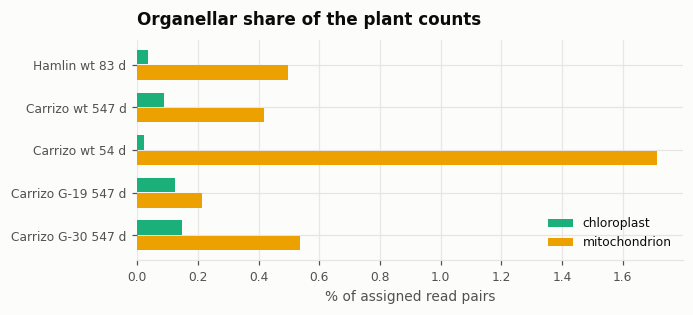

In [5]:
where = contig.map(ORGANELLE).fillna("nuclear")
biotype = annot["gene_biotype"].reindex(counts.index).fillna("(unannotated)")
keep = (biotype == "protein_coding") & (where == "nuclear")

by_type = biotype.value_counts().rename("genes").to_frame()
by_type["share_of_pairs_%"] = (counts.groupby(biotype).sum().sum(axis=1) / counts.sum().sum() * 100).round(2)
display(by_type.sort_values("genes", ascending=False).T)

org_share = counts.groupby(where).sum().T.div(counts.sum(), axis=0) * 100
fig, ax = plt.subplots(figsize=(6.4, 2.6))
y = np.arange(len(GALLS))
ax.barh(y - 0.18, org_share.loc[GALLS, "chloroplast"], 0.34, color=gv.SERIES[2], label="chloroplast")
ax.barh(y + 0.18, org_share.loc[GALLS, "mitochondrion"], 0.34, color=gv.SERIES[3], label="mitochondrion")
ax.set_yticks(y, [LABEL[s] for s in GALLS]); ax.invert_yaxis()
ax.set_xlabel("% of assigned read pairs"); ax.legend(loc="lower right")
ax.set_title("Organellar share of the plant counts")
gv.clean(ax, "x"); gv.save(fig, "shortlist_organellar_share")
print(f"kept for ranking: {keep.sum():,} protein-coding nuclear genes of {len(keep):,}")

The organellar share is small in every gall, as expected for polyA-selected libraries (`README.md` §3:
about 1 % intronic reads, polyA mRNA). Dropping them changes nothing about the rankings but keeps
chloroplast genes out of a promoter list.

## 3. TPM and within-gall percentile

Counts become TPM (pairs / gene length in kb, scaled to a million over all counted genes), then each
gene gets its **percentile among the kept genes within each gall** (1.0 = most expressed). Percentiles
are what the ranking methods compare: they are immune to sequencing depth and to the library-size
differences between the galls and, later, the public baselines.

,Hamlin wt 83 d,Carrizo wt 547 d,Carrizo wt 54 d,Carrizo G-19 547 d,Carrizo G-30 547 d
top 20,11.5,10.4,10.3,16.8,19.4
top 100,23.7,22.5,23.2,28.3,31.2
top 1000,56.6,56.4,58.1,59.5,61.7


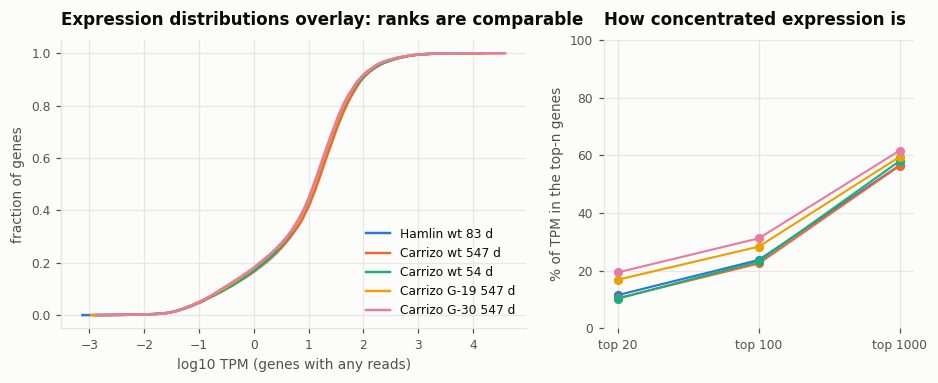

In [6]:
rpk = counts.div(gene_len / 1000, axis=0)
tpm = rpk.div(rpk.sum()) * 1e6
tpm_k = tpm[keep]
pct = tpm_k.rank(pct=True, method="average")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw=dict(width_ratios=[3, 2]))
ax = axes[0]
for s in GALLS:
    v = np.sort(np.log10(tpm_k[s][tpm_k[s] > 0]))
    ax.plot(v, np.linspace(0, 1, len(v)), color=GALL_COLOR[s], label=LABEL[s], lw=1.6)
ax.set_xlabel("log10 TPM (genes with any reads)"); ax.set_ylabel("fraction of genes")
ax.set_title("Expression distributions overlay: ranks are comparable"); ax.legend(loc="lower right")
gv.clean(ax, "both")

conc = pd.DataFrame({LABEL[s]: [tpm_k[s].sort_values(ascending=False).head(n).sum() / tpm_k[s].sum() * 100
                                 for n in (20, 100, 1000)] for s in GALLS}, index=["top 20", "top 100", "top 1000"])
ax = axes[1]
for i, s in enumerate(GALLS):
    ax.plot(conc.index, conc[LABEL[s]], marker="o", color=GALL_COLOR[s], lw=1.4, ms=5)
ax.set_ylabel("% of TPM in the top-n genes"); ax.set_ylim(0, 100)
ax.set_title("How concentrated expression is"); gv.clean(ax, "y")
gv.save(fig, "shortlist_tpm_distributions")
conc.round(1)

## 4. Do the five galls agree?

If the galls disagreed wildly, a joint list would be meaningless. Spearman correlation of log TPM says
how similar the transcriptomes are; the scatter shows where the top-20 genes sit when Hamlin is
compared with the wild-type Carrizo galls.

,29wtHC83,1416wtCC547,1416wtCC54,1416G-19CC547,1416G-30CC547
29wtHC83,1.000,0.860,0.879,0.783,0.779
1416wtCC547,0.860,1.000,0.853,0.859,0.881
1416wtCC54,0.879,0.853,1.000,0.801,0.794
1416G-19CC547,0.783,0.859,0.801,1.000,0.960
1416G-30CC547,0.779,0.881,0.794,0.960,1.000


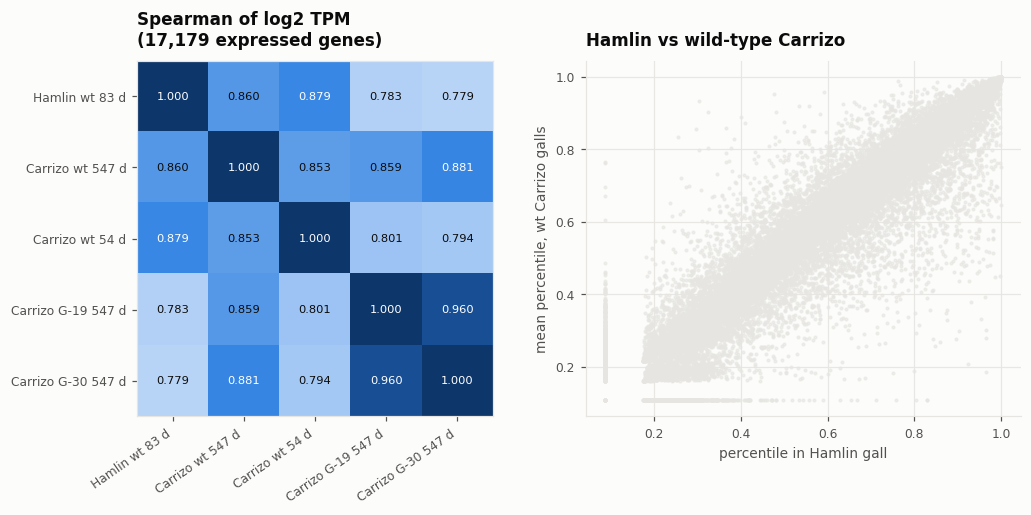

In [5]:
lt = np.log2(tpm_k + 1)
expressed = (tpm_k > 1).any(axis=1)
corr = lt[expressed].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), gridspec_kw=dict(width_ratios=[1, 1.15]))
ax = axes[0]
im = ax.imshow(corr.values, cmap=gv.SEQ, vmin=corr.values.min() - 0.02, vmax=1)
ax.set_xticks(range(5), [LABEL[s] for s in GALLS], rotation=35, ha="right")
ax.set_yticks(range(5), [LABEL[s] for s in GALLS])
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{corr.values[i, j]:.3f}", ha="center", va="center", fontsize=7.5,
                color="white" if corr.values[i, j] > corr.values.mean() else gv.INK)
ax.set_title(f"Spearman of log2 TPM\n({expressed.sum():,} expressed genes)"); ax.grid(False)

ax = axes[1]
x, yv = pct["29wtHC83"], pct[GROUPS["carrizo_wt"]].mean(axis=1)
ax.scatter(x, yv, s=3, color=gv.GRID, alpha=0.6, rasterized=True, label="all kept genes")
ax.set_xlabel("percentile in Hamlin gall"); ax.set_ylabel("mean percentile, wt Carrizo galls")
ax.set_title("Hamlin vs wild-type Carrizo"); gv.clean(ax, "both")
ax_corr_ax = ax   # the top-20 overlay is added in §5 once the lists exist
gv.save(fig, "shortlist_gall_concordance")
corr.round(3)

Two axes show up, not one. G-19 and G-30 are near-replicates (Spearman 0.96) and, with the wild-type
547-day gall, the three **old** Carrizo galls form the tightest block (0.86-0.88). The two **young** galls,
Carrizo 54 d and Hamlin 83 d, are closer to each other (0.88) than to the old galls of their own genotype
(0.78-0.85). So gall age matters as much as host or strain, and the engineered galls also have a more
top-heavy transcriptome (§3: the top 20 genes hold 17-19 % of TPM, against 10-12 % in the others,
driven by LEA5 and the MLP423-like gene). The groups still follow the plan (genotype and strain, which
is what the follow-up experiment varies), but when reading the merged lists, treat "young vs old gall"
as a hidden factor: a gene unique to the `carrizo_wt` list may be an age effect, since that group mixes
one young and one old gall.

## 5. Method 1: expression in the galls

Score of a gene in a group = its **lowest percentile across that group's galls**; ties break on mean TPM.
So a gene tops the `all` list only if it is near the top in every one of the five galls. This is the
"promoter strength" axis: it says nothing yet about whether the gene is gall-specific.
`paralogs` = number of citrus genes sharing the same best Arabidopsis hit (a rough multi-copy warning).
The same computation is `make shortlist` (`scripts/shortlist_expression.py`); the cell checks that both agree.

In [7]:
score1 = pd.DataFrame({g: pct[m].min(axis=1) for g, m in GROUPS.items()})
mean_tpm = pd.DataFrame({g: tpm_k[m].mean(axis=1) for g, m in GROUPS.items()})
agi_n = annot.loc[annot["ath_agi"] != "", "ath_agi"].value_counts()
paralogs = annot["ath_agi"].map(agi_n).fillna(0).astype(int).reindex(tpm_k.index).fillna(0).astype(int)

def ranked(group, score, tiebreak=None, ascending=False):
    order = pd.DataFrame({"s": score, "t": (tiebreak if tiebreak is not None else mean_tpm[group])})
    return order.sort_values(["s", "t"], ascending=[ascending, False]).index

top1 = {g: ranked(g, score1[g])[:TOP] for g in GROUPS}

for g in GROUPS:
    f = OUT / f"method1_expression_{g}_top20.tsv"
    if f.exists():
        same = set(pd.read_csv(f, sep="\t")["gene_id"]) == set(top1[g])
        print(f"{g:12s} top {TOP} agrees with scripts/shortlist_expression.py: {same}")

def table(group, genes, score, score_name="score"):
    t = pd.DataFrame({score_name: score.reindex(genes)})
    for s in GALLS:
        t[LABEL[s]] = tpm_k.loc[genes, s].round(0).astype(int)
    t["paralogs"] = paralogs.reindex(genes)
    t = t.join(annot[ANN])
    t.insert(0, "rank", range(1, len(t) + 1))
    t.index.name = "gene"
    return t

table("all", top1["all"], score1["all"], "min pct").style.format({"min pct": "{:.4f}"})

hamlin       top 20 agrees with scripts/shortlist_expression.py: True
carrizo_wt   top 20 agrees with scripts/shortlist_expression.py: True
carrizo_eng  top 20 agrees with scripts/shortlist_expression.py: True
all          top 20 agrees with scripts/shortlist_expression.py: True


,rank,min pct,Hamlin wt 83 d,Carrizo wt 547 d,Carrizo wt 54 d,Carrizo G-19 547 d,Carrizo G-30 547 d,paralogs,refseq_description,em_preferred_name,ath_symbol,ath_agi,ath_rbh
gene,,,,,,,,,,,,,
gene-LOC102621613,1,0.9998,6806,10473,7288,15484,18961,10,major allergen Pru ar 1,,MLP423,AT1G24020,0
gene-CYP,2,0.9997,8986,11373,15266,6719,7439,1,peptidyl-prolyl cis-trans isomerase-like,ROC1,ROC3,AT2G16600,1
gene-LOC102620682,3,0.9997,6497,8508,4864,7663,16209,0,uncharacterized LOC102620682,,,,
gene-LOC102617427,4,0.9996,6896,7231,6989,4853,5333,1,metallothionein-like protein type 2,MT2A,MT2A,AT3G09390,1
gene-LEA5,5,0.9990,2435,12873,6646,24018,38437,2,late embryogenesis abundant protein Lea5-like,LEA5,SAG21,AT4G02380,0
gene-LOC127902716,6,0.9990,8566,4127,8805,2160,3364,0,extensin-3,,,,
gene-LOC102622469,7,0.9990,3437,3546,3869,2123,2744,2,60S ribosomal protein L27,RPL27,AT4G15000,AT4G15000,1
gene-LOC102628665,8,0.9989,3237,2130,2308,4906,5127,1,glycine-rich RNA-binding protein-like,GRP1,GRP7,AT2G21660,1
gene-LOC102624646,9,0.9988,2253,2769,2267,3879,3294,2,thioredoxin H-type,,TRX1,AT3G51030,1


In [7]:
short = {g: (table(g, top1[g], score1[g], "min pct")[["rank", "min pct", "refseq_description", "ath_symbol"]]
             .rename(columns={"min pct": "score"}))
         for g in ("hamlin", "carrizo_wt", "carrizo_eng")}
for g, t in short.items():
    print(f"\n=== {g}: galls {', '.join(LABEL[s] for s in GROUPS[g])}")
    display(t.style.format({"score": "{:.4f}"}))


=== hamlin: galls Hamlin wt 83 d


,rank,score,refseq_description,ath_symbol
gene,,,,
gene-LOC102607844,1,1.0000,protein SRC1-like,AT1G54410
gene-CYP,2,1.0000,peptidyl-prolyl cis-trans isomerase-like,ROC3
gene-LOC127902716,3,0.9999,extensin-3,
gene-LOC102618061,4,0.9999,polyubiquitin 11,UBQ11
gene-LOC102617427,5,0.9998,metallothionein-like protein type 2,MT2A
gene-LOC102621613,6,0.9998,major allergen Pru ar 1,MLP423
gene-LOC102620682,7,0.9997,uncharacterized LOC102620682,
gene-LOC102578039,8,0.9997,"early light-induced protein 1, chloroplastic",ELIP1
gene-LOC102618921,9,0.9997,aquaporin PIP1-2,PIP1;4



=== carrizo_wt: galls Carrizo wt 547 d, Carrizo wt 54 d


,rank,score,refseq_description,ath_symbol
gene,,,,
gene-CYP,1,1.0000,peptidyl-prolyl cis-trans isomerase-like,ROC3
gene-LOC102621613,2,0.9999,major allergen Pru ar 1,MLP423
gene-LEA5,3,0.9998,late embryogenesis abundant protein Lea5-like,SAG21
gene-LOC102617427,4,0.9998,metallothionein-like protein type 2,MT2A
gene-LOC102620682,5,0.9997,uncharacterized LOC102620682,
gene-LOC127902716,6,0.9997,extensin-3,
gene-LOC102622469,7,0.9997,60S ribosomal protein L27,AT4G15000
gene-LOC127900537,8,0.9994,non-specific lipid-transfer protein 2-like,AT3G18280
gene-LOC102630124,9,0.9994,aquaporin TIP1-1,GAMMA-TIP



=== carrizo_eng: galls Carrizo G-19 547 d, Carrizo G-30 547 d


,rank,score,refseq_description,ath_symbol
gene,,,,
gene-LOC102620812,1,1.0000,inhibitor of trypsin and hageman factor-like,AT2G38870
gene-LEA5,2,1.0000,late embryogenesis abundant protein Lea5-like,SAG21
gene-LOC102621613,3,0.9999,major allergen Pru ar 1,MLP423
gene-LOC102631364,4,0.9998,21 kDa seed protein-like,AT1G17860
gene-LOC102620682,5,0.9998,uncharacterized LOC102620682,
gene-LOC102614003,6,0.9998,translationally-controlled tumor protein homolog,TCTP
gene-CYP,7,0.9997,peptidyl-prolyl cis-trans isomerase-like,ROC3
gene-LOC102628172,8,0.9997,endochitinase-like,HCHIB
gene-LOC102608938,9,0.9996,dnaJ protein homolog,J3


### Reading the method-1 lists

- **The `all` list is the constitutive-promoter set.** Ribosomal proteins, polyubiquitin, cyclophilin
  (ROC1), metallothionein MT2A, NDPK1, translationally-controlled tumour protein: strong in every tissue
  of every plant. As reporter-driver candidates they promise *strength*, not gall specificity; the
  classic choices (ubiquitin, actin-like) come from exactly this kind of list.
- **Mixed in are stress/wound genes**: the rank-1 MLP423-like major allergen (Bet v 1 family), LEA5/SAG21,
  dehydrin ERD14, glycine-rich RNA-binding GRP7, extensins. These are the interesting candidates: high in
  every gall, and plausibly induced by the gall rather than merely housekeeping. Whether they are *up*
  relative to healthy tissue is the baseline question (§7).
- **Hamlin** adds aquaporins (PIP1, PIP2, TIP1) and more extensins, both cell-wall/water-transport
  programs consistent with a rapidly expanding tissue, but Hamlin is n = 1 and a different host, so treat
  its unique entries as hypotheses.
- **G-19/G-30** add protease inhibitors, an endochitinase, dormancy-associated DYL1 and VAMP721: a
  defence flavour that the wild-type galls lack at the very top. The engineered galls barely express the
  wild-type T-DNA (`README.md` §6.3), so their list is the closest thing to an "engineered-strain gall"
  promoter set.

42 genes in at least one method-1 list; in how many lists:
1    23
2     7
3     5
4     7


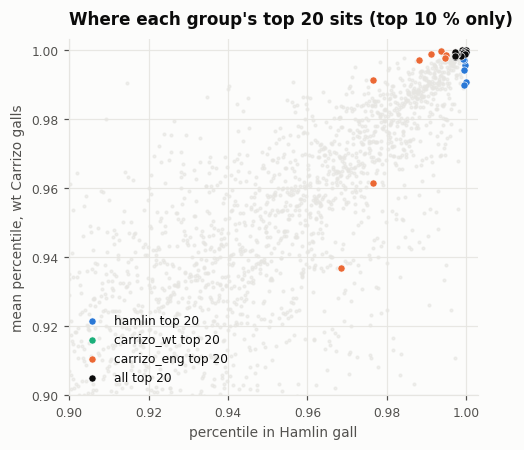

In [8]:
# overlay the `all` top 20 on the concordance scatter from section 4
fig, ax = plt.subplots(figsize=(4.8, 4.2))
x, yv = pct["29wtHC83"], pct[GROUPS["carrizo_wt"]].mean(axis=1)
ax.scatter(x, yv, s=3, color=gv.GRID, alpha=0.6, rasterized=True)
for g, c in (("hamlin", gv.SERIES[0]), ("carrizo_wt", gv.SERIES[2]), ("carrizo_eng", gv.SERIES[1]), ("all", gv.INK)):
    ax.scatter(x[top1[g]], yv[top1[g]], s=22, color=c, label=f"{g} top {TOP}", edgecolor="white", lw=0.4)
ax.set_xlim(0.9, 1.003); ax.set_ylim(0.9, 1.003)
ax.set_xlabel("percentile in Hamlin gall"); ax.set_ylabel("mean percentile, wt Carrizo galls")
ax.set_title("Where each group's top 20 sits (top 10 % only)"); ax.legend(loc="lower left")
gv.clean(ax, "both"); gv.save(fig, "shortlist_top20_scatter")

union = [g for g in ranked("all", score1["all"]) if any(g in top1[k] for k in GROUPS)]
member = pd.DataFrame({k: [g in top1[k] for g in union] for k in GROUPS}, index=union)
print(f"{len(union)} genes in at least one method-1 list; in how many lists:")
print(member.sum(axis=1).value_counts().sort_index().rename("genes").to_string())

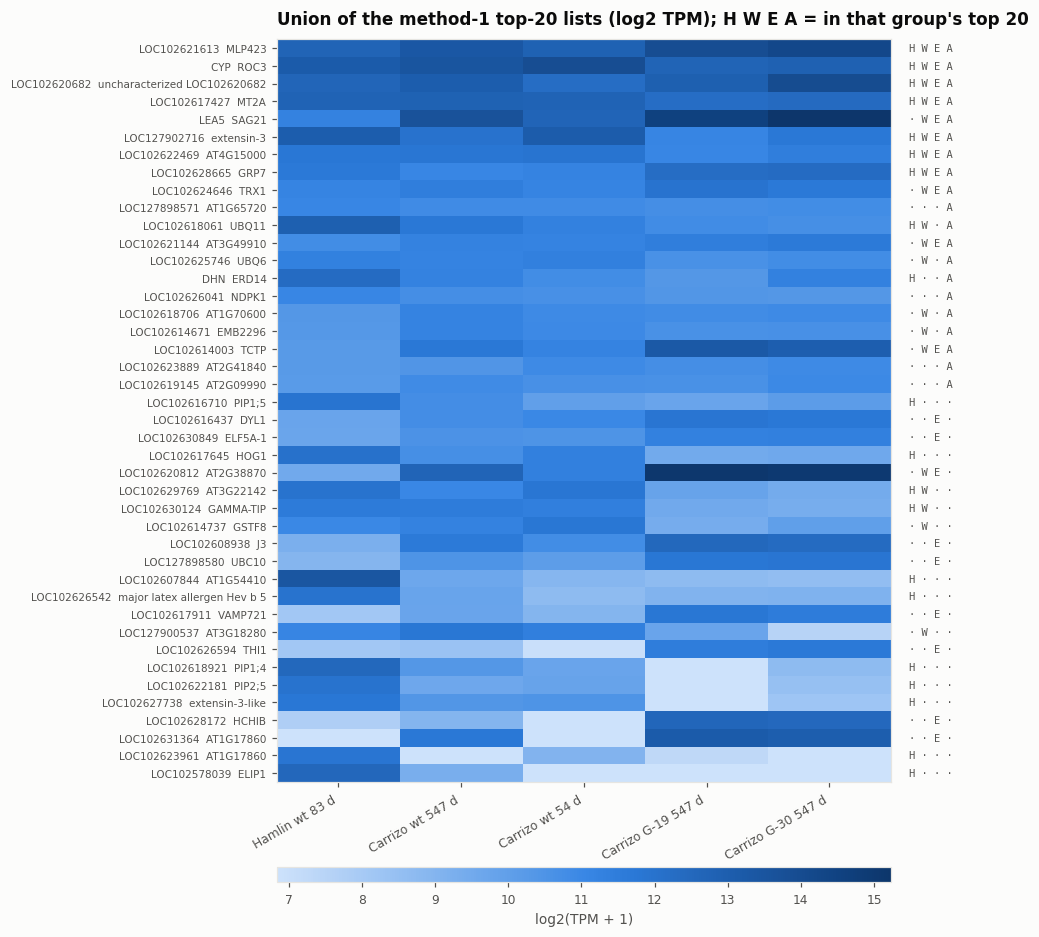

In [9]:
# heatmap of the union: log2 TPM per gall, rows ordered by the `all` score, list membership at right
M = np.log2(tpm_k.loc[union] + 1)
fig, ax = plt.subplots(figsize=(7.2, 0.21 * len(union) + 1.2))
im = ax.imshow(M.values, cmap=gv.SEQ, aspect="auto", vmin=np.percentile(M.values, 5), vmax=M.values.max())
ax.set_xticks(range(5), [LABEL[s] for s in GALLS], rotation=30, ha="right")
labels = [f"{g.replace('gene-', '')}  {(annot.at[g, 'ath_symbol'] or annot.at[g, 'refseq_description'][:28]) if g in annot.index else ''}"
          for g in union]
ax.set_yticks(range(len(union)), labels, fontsize=6.8)
FLAG = {"hamlin": "H", "carrizo_wt": "W", "carrizo_eng": "E", "all": "A"}
for i, g in enumerate(union):
    flags = " ".join(FLAG[k] if member.at[g, k] else "·" for k in GROUPS)
    ax.text(4.65, i, flags, va="center", fontsize=6.8, family="monospace", color=gv.INK2, clip_on=False)
ax.grid(False); ax.set_title("Union of the method-1 top-20 lists (log2 TPM); H W E A = in that group's top 20")
cb = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.025, pad=0.1, aspect=40); cb.set_label("log2(TPM + 1)")
gv.save(fig, "shortlist_method1_heatmap");

## 6. Multi-copy and cloning warnings

A promoter is only useful if it can be cloned unambiguously. Two cheap flags from the annotation:
`paralogs` > 1 (several citrus genes share the same best Arabidopsis hit, so a gene family) and
`ath_rbh` = 0 (the Arabidopsis hit is not reciprocal, so the naming is loose). Neither excludes a gene;
they mark where the promoter sequence should be checked against its paralogs before ordering primers.

In [10]:
warn = table("all", union, score1["all"], "score_all")[["score_all", "paralogs", "ath_rbh", "ath_symbol", "refseq_description"]]
warn = warn[(warn["paralogs"] > 1) | (warn["ath_rbh"] != "1")].sort_values("paralogs", ascending=False)
print(f"{len(warn)} of the {len(union)} union genes carry a warning")
warn.style.format({"score_all": "{:.4f}"})

27 of the 42 union genes carry a warning


,score_all,paralogs,ath_rbh,ath_symbol,refseq_description
gene,,,,,
gene-LOC102631364,0.6681,17,0,AT1G17860,21 kDa seed protein-like
gene-LOC102623961,0.3434,17,0,AT1G17860,kunitz trypsin inhibitor 5-like
gene-LOC102621613,0.9998,10,0,MLP423,major allergen Pru ar 1
gene-LOC127898580,0.9880,8,0,UBC10,ubiquitin-conjugating enzyme E2 28
gene-LOC102620812,0.9936,4,1,AT2G38870,inhibitor of trypsin and hageman factor-like
gene-LOC102628172,0.8864,4,0,HCHIB,endochitinase-like
gene-LOC102629769,0.9931,4,1,AT3G22142,extensin-like
gene-LOC102630849,0.9948,3,1,ELF5A-1,eukaryotic translation initiation factor 5A-2
gene-LOC102614737,0.9927,3,1,GSTF8,glutathione S-transferase F6


## 7. Methods 3, 4 and 6: against the public healthy-tissue baselines

These need `04_matrix/baseline_citrus_sinensis.tsv` from `make baselines` (README.md step 5c: the tier-1
runs of `citrus_baselines.tsv`, same fastp/HISAT2/featureCounts settings, plant-only index). Baselines are
matched by genotype: Carrizo galls against the Carrizo runs (PRJNA1216034 stem and leaves), Hamlin
against the sweet-orange runs (PRJNA599503 bark/root/leaf, PRJNA778304 callus), `all` against everything.
Genes must be clearly expressed in the galls (TPM >= 5 in every gall of the group) before ranking.

- **Method 3, percentile shift**: gall percentile minus the median baseline percentile, minimum over the
  group's galls.
- **Method 4, rank products** (Breitling 2004): per gall, rank genes by log2 fold change vs the median
  baseline TPM; a gene's score is the geometric mean of its ranks across the group's galls.
- **Method 6, tau** (Yanai 2005): tissue specificity over gall + each baseline tissue, using mean
  log2(TPM+1) per tissue; only genes whose top tissue is the gall are ranked.

Until the job has finished, the cells below just report that the matrix is pending.

In [11]:
BASELINE = Path(os.environ.get("GALLRNA_BASELINE", ROOT / "04_matrix" / "baseline_citrus_sinensis.tsv"))
SUMMARY = ROOT / "logs" / "baseline_summary.tsv"
runs = pd.read_csv(ROOT / "citrus_baselines.tsv", sep="\t", index_col="run")
HAVE_BASELINE = BASELINE.exists()

if HAVE_BASELINE:
    bcounts = pd.read_csv(BASELINE, sep="\t", index_col="gene")
    brun = runs.loc[bcounts.columns]
    brpk = bcounts.div(gene_len.reindex(bcounts.index) / 1000, axis=0)
    btpm_k = (brpk.div(brpk.sum()) * 1e6).reindex(tpm_k.index)
    bpct = btpm_k.rank(pct=True, method="average")
    BSET = {"hamlin": brun.index[brun["host_ref"] == "citrus_sinensis"],
            "carrizo_wt": brun.index[brun["host_ref"] == "carrizo"],
            "carrizo_eng": brun.index[brun["host_ref"] == "carrizo"],
            "all": brun.index}
    print(f"baselines: {bcounts.shape[1]} runs from {brun['bioproject'].nunique()} BioProjects")
    display(brun.groupby(["host_ref", "bioproject", "tissue"]).size().rename("runs").to_frame().T)
    if SUMMARY.exists():
        display(pd.read_csv(SUMMARY, sep="\t").set_index("run"))
else:
    print(f"pending: {BASELINE.relative_to(ROOT)} not there yet (make baselines / scripts/baselines.slurm)")

pending: 04_matrix/baseline_citrus_sinensis.tsv not there yet (make baselines / scripts/baselines.slurm)


In [12]:
if HAVE_BASELINE:
    # QC: do the baselines cluster by tissue/study, and where do the galls fall?
    allt = pd.concat([tpm_k, btpm_k], axis=1)
    lab = [LABEL[s] for s in GALLS] + [f"{r}  {brun.at[r, 'host_ref'][:7]} {brun.at[r, 'tissue']}" for r in btpm_k.columns]
    c2 = np.log2(allt[(allt > 1).any(axis=1)] + 1).corr(method="spearman")
    n = len(lab)
    fig, ax = plt.subplots(figsize=(0.28 * n + 2, 0.28 * n + 1.5))
    im = ax.imshow(c2.values, cmap=gv.SEQ, vmin=np.percentile(c2.values, 2), vmax=1)
    ax.set_xticks(range(n), lab, rotation=90, fontsize=6.5); ax.set_yticks(range(n), lab, fontsize=6.5)
    ax.axhline(4.5, color=gv.SURFACE, lw=2); ax.axvline(4.5, color=gv.SURFACE, lw=2)
    ax.grid(False); ax.set_title("Galls (first five) vs baselines: Spearman of log2 TPM")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    gv.save(fig, "shortlist_gall_vs_baseline_corr")
    display(c2.iloc[:5, 5:].T.round(3).describe().loc[["min", "50%", "max"]].round(3))

In [13]:
if HAVE_BASELINE:
    score3, score4, score6, top3, top4, top6, tau_tab = {}, {}, {}, {}, {}, {}, {}
    for g, members in GROUPS.items():
        bs = BSET[g]
        clear = (tpm_k[members] >= 5).all(axis=1)
        # method 3: percentile shift
        shift = pct[members].sub(bpct[bs].median(axis=1), axis=0).min(axis=1).where(clear, -1)
        score3[g] = shift
        top3[g] = ranked(g, shift)[:TOP]
        # method 4: rank products of per-gall log2FC vs the median baseline
        ref = btpm_k[bs].median(axis=1)
        lfc = np.log2(tpm_k[members].add(1, axis=0).div(ref + 1, axis=0))
        rk = lfc.rank(ascending=False)
        rp = np.exp(np.log(rk).mean(axis=1)).where(clear, np.inf)
        score4[g] = rp
        top4[g] = ranked(g, rp, ascending=True)[:TOP]
        # method 6: tau across gall + baseline tissues
        tissues = {"gall": tpm_k[members].mean(axis=1)}
        for t, rs in brun.loc[bs].groupby("tissue").groups.items():
            tissues[t] = btpm_k[list(rs)].mean(axis=1)
        X = np.log2(pd.DataFrame(tissues) + 1)
        tau = (1 - X.div(X.max(axis=1), axis=0)).sum(axis=1) / (X.shape[1] - 1)
        gall_top = X.idxmax(axis=1) == "gall"
        tau = tau.where(clear & gall_top, -1)
        score6[g] = tau
        top6[g] = ranked(g, tau)[:TOP]
        tau_tab[g] = X
    score3, score4, score6 = pd.DataFrame(score3), pd.DataFrame(score4), pd.DataFrame(score6)
    for g in GROUPS:
        print(f"{g:12s} baselines {len(BSET[g]):2d}  clearly expressed {int((tpm_k[GROUPS[g]] >= 5).all(axis=1).sum()):,}  "
              f"tissues for tau: {', '.join(tau_tab[g].columns)}")

In [14]:
if HAVE_BASELINE:
    for g in GROUPS:
        t = table(g, top3[g], score3[g], "pct shift")
        t["rank products"] = score4[g].reindex(t.index).round(0)
        t["tau"] = score6[g].reindex(t.index).round(3)
        print(f"\n=== method 3 (percentile shift), {g}")
        display(t[["rank", "pct shift", "rank products", "tau"] + [LABEL[s] for s in GROUPS[g]] + ["paralogs", "ath_symbol", "refseq_description"]]
                .style.format({"pct shift": "{:.3f}", "rank products": "{:.0f}", "tau": "{:.3f}"}))

In [15]:
if HAVE_BASELINE:
    # strength (method 1) against specificity (method 3): the two axes of the decision
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
    for ax, g in zip(axes, GROUPS):
        ok = score3[g] > -1
        ax.scatter(score1[g][ok], score3[g][ok], s=3, color=gv.GRID, alpha=0.5, rasterized=True)
        for genes, c, lbl in ((top1[g], gv.INK, "method 1"), (top3[g], gv.SERIES[1], "method 3"),
                              (top4[g], gv.SERIES[0], "method 4"), (top6[g], gv.SERIES[2], "method 6")):
            ax.scatter(score1[g][genes], score3[g][genes], s=16, color=c, label=f"{lbl} top {TOP}", edgecolor="white", lw=0.3)
        ax.axhline(0, color=gv.INK2, lw=0.8, ls=":")
        ax.set_title(g); ax.set_xlabel("method 1: min percentile in galls")
        gv.clean(ax, "both")
    axes[0].set_ylabel("method 3: percentile shift vs baseline"); axes[0].legend(loc="lower left", fontsize=7)
    gv.save(fig, "shortlist_strength_vs_shift");

In [16]:
if HAVE_BASELINE:
    # merged table per group: rank under every available method, for the genes in any top-20
    merged = {}
    for g in GROUPS:
        rank_of = {"m1_expression": ranked(g, score1[g]), "m3_pct_shift": ranked(g, score3[g]),
                   "m4_rank_products": ranked(g, score4[g], ascending=True), "m6_tau": ranked(g, score6[g])}
        picks = [x for x in rank_of["m1_expression"] if any(x in top for top in (top1[g], top3[g], top4[g], top6[g]))]
        t = pd.DataFrame({f"rank_{k}": pd.Series(range(1, len(v) + 1), index=v).reindex(picks) for k, v in rank_of.items()})
        t["n_lists"] = (t <= TOP).sum(axis=1)
        for s in GROUPS[g]:
            t[f"tpm_{s}"] = tpm_k.loc[picks, s].round(1)
        t["tpm_baseline_median"] = btpm_k.loc[picks, BSET[g]].median(axis=1).round(1)
        t["paralogs"] = paralogs.reindex(picks)
        t = t.join(annot[ANN]).sort_values(["n_lists", "rank_m3_pct_shift"], ascending=[False, True])
        t.index.name = "gene_id"
        t.to_csv(OUT / f"merged_{g}.tsv", sep="\t")
        merged[g] = t
        print(f"{g:12s} {len(t):3d} genes in any list; in 2+ lists: {(t['n_lists'] >= 2).sum()}, in 3+: {(t['n_lists'] >= 3).sum()}  -> results/shortlist/merged_{g}.tsv")
    display(merged["carrizo_wt"].head(25))

### Interpretation, methods 3-6

*To be written once the baseline job has landed: the section above executes then.* The questions to
answer here: (1) does the gall show the canonical crown-gall program (plan §3.4: photosynthesis down,
fermentation and sugar transport up), which validates the baselines; (2) which of the method-1 stress
genes are actually up vs healthy tissue; (3) what the genes in two or more lists are, per group; (4) which
candidates are gall-specific (tau) rather than merely proliferation-like (up vs stem/bark but at callus level).

## 8. Next

1. When `make baselines` is done, re-execute this notebook and fill in §7's interpretation.
2. Method 2 (DESeq2 with `lfcShrink`) once R/DESeq2 is installed (README.md step 6); method 5 (RankComp)
   if the simple methods disagree.
3. Hand review of `results/shortlist/merged_<group>.tsv` against `genes.tsv`, then ~1.5 kb upstream
   sequences for the picks (plan §4 F), and the T-DNA promoters as bacterial benchmarks (plan §1.2).